# Implementation of Castability Through Translation or Rotation

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrow
import polygenerator as pg
import seaborn as sns
from sklearn.preprocessing import normalize

sns.set_style('whitegrid')

## Setting up helper functions

In [168]:
x = np.array([0, 0.5, 1])
y = np.array([1, 0, 1])

poly1 = np.column_stack([x, y])
poly1

array([[0. , 1. ],
       [0.5, 0. ],
       [1. , 1. ]])

In [169]:
rand_poly = np.array(pg.random_polygon(8))

In [170]:
def plot_polygon(polygon):
    poly = None
    if isinstance(polygon, Polygon):
        poly = polygon
    else:
        poly = Polygon(polygon, facecolor='lightgray',
                       alpha=0.9, edgecolor='black')

    ax = plt.subplot()
    fill_shape = np.array([(1, 1), (1, 0), (0, 0), (0, 1)])
    fill_shape = np.concat([fill_shape, poly.get_xy()])
    fill_shape = Polygon(fill_shape, closed=True, color='pink', alpha=0.5)

    ax.add_patch(fill_shape)
    ax.add_patch(poly)

    plt.show()

In [171]:
def get_edges(points):
    if isinstance(points, Polygon):
        return np.stack((points.get_xy(), np.roll(points.get_xy(), -1, axis=0)), axis=1)[:-1]
    else:
        return np.stack((points, np.roll(points, -1, axis=0)), axis=1)[:-1]
    

In [172]:
def get_perp_angle(edge):
    x = edge[1, 0] - edge[0, 0]
    y = edge[1, 1] - edge[0, 1]
    
    if x > 0:
        return np.arctan(y/x) + np.pi/2
    else:
        return np.arctan2(y,x) + np.pi/2

In [173]:
def get_angle(edge):
    x = edge[1, 0] - edge[0, 0]
    y = edge[1, 1] - edge[0, 1]
    
    if x > 0:
        return np.arctan(y/x)
    else:
        return np.arctan2(y,x)

In [174]:
def get_angle_bounds(angle):
    lower = angle-np.pi/2
    
    upper = angle+np.pi/2
    
    return (lower, upper)

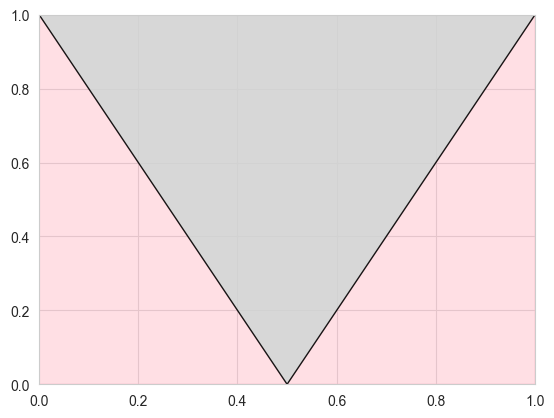

In [175]:
plot_polygon(poly1)

# Translatable Polygon

In [176]:
def translatable(poly1):

    poly1_edges = get_edges(poly1)

    angle_boundaries = np.empty((len(poly1_edges), 2))
    for i, edge in enumerate(poly1_edges):
        angle_boundaries[i] = get_angle_bounds(get_perp_angle(edge))

    min_angle = 0
    max_angle = np.pi

    for lower, upper in angle_boundaries:
        if min_angle > upper or max_angle < lower or min_angle > max_angle:
            return -1
        
        if min_angle < lower:
            min_angle = lower

        if max_angle > upper:

            max_angle = upper

    theta = (min_angle+max_angle)/2

    return (np.round(np.cos(theta), 3)/2, np.round(np.sin(theta), 3)/2)

In [177]:
translatable(poly1)

(np.float64(0.0), np.float64(0.5))

In [178]:
def plot_translated(polygon):
    translation_vector = translatable(polygon)

    if translation_vector == -1:
        return -1

    translated = polygon.copy()

    for i in range(len(translated)):
        translated[i] = translated[i] + translation_vector

    ax = plt.subplot()

    fill_shape = np.array([(1, 1), (1, 0), (0, 0), (0, 1)])
    fill_shape = np.concat([fill_shape, polygon])
    fill_shape = Polygon(fill_shape, closed=True, color='pink', alpha = 0.5)

    ax.add_patch(fill_shape)
    ax.add_patch(Polygon(polygon, fill=False, edgecolor='black',
                 linestyle='--', linewidth=2))
    ax.add_patch(Polygon(translated, facecolor = 'lightgray', alpha = 0.9, edgecolor = 'black', lw = 1))

    center_x, center_y = np.mean(polygon, axis=0)

    arrow = FancyArrow(
        center_x, center_y, translation_vector[0], translation_vector[1], color='black', head_width=0.02, width=0.005)
    ax.add_patch(arrow)

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.05, 1.6)

## Demonstration: Triangle

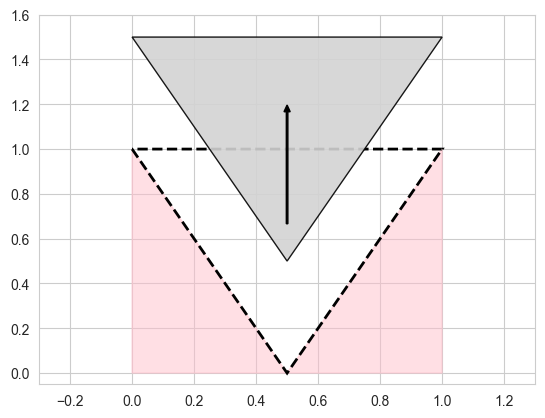

In [179]:
plot_translated(poly1)

## Demonstration: Not translatable nor rotatable (poly2)

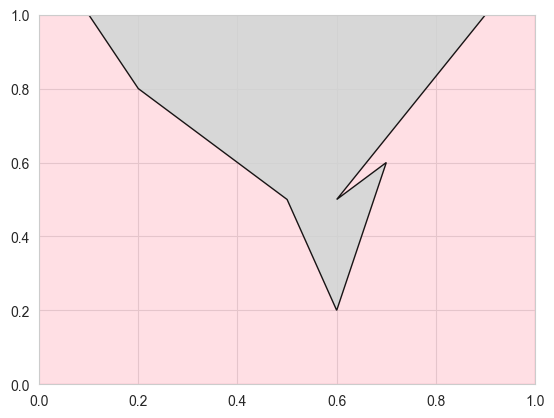

In [180]:
poly2 = np.array([
                    [0.1, 1], 
                    [0.2, 0.8],
                    [0.5, 0.5],
                    [0.6, 0.2],
                    [0.7, 0.6],
                    [0.6, 0.5],
                    [0.9, 1]
                ])

plot_polygon(poly2)

In [181]:
plot_translated(poly2)

-1

## Demonstration: Translatable, example from class

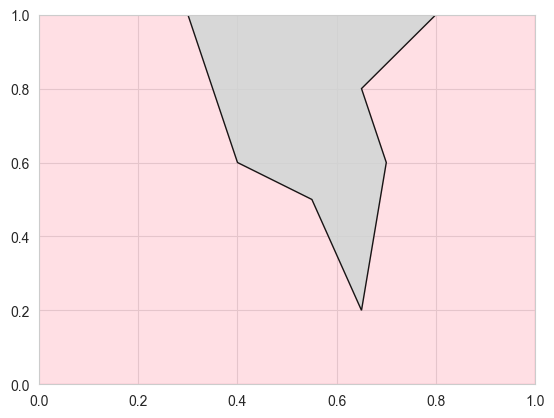

In [182]:
poly3 = np.array([
                    [0.3, 1], 
                    [0.4, 0.6],
                    [0.55, 0.5],
                    [0.65, 0.2],
                    [0.7, 0.6],
                    [0.65, 0.8],
                    [0.8, 1]
                ])

plot_polygon(poly3)

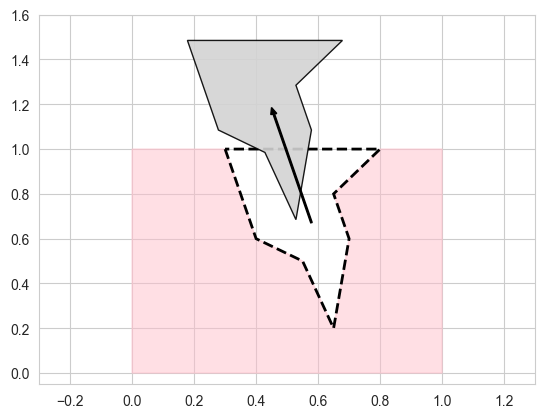

In [183]:
plot_translated(poly3)

## Demonstration: Parallelogram

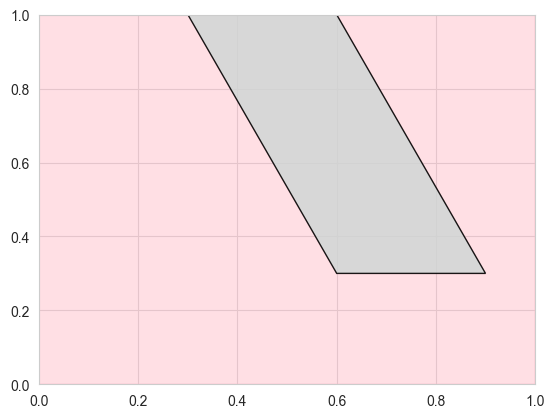

In [184]:
poly4 = np.array([
                    [0.3, 1], 
                    [0.6, 0.3],
                    [0.9, 0.3],
                    [0.6, 1]
                ])

plot_polygon(poly4)

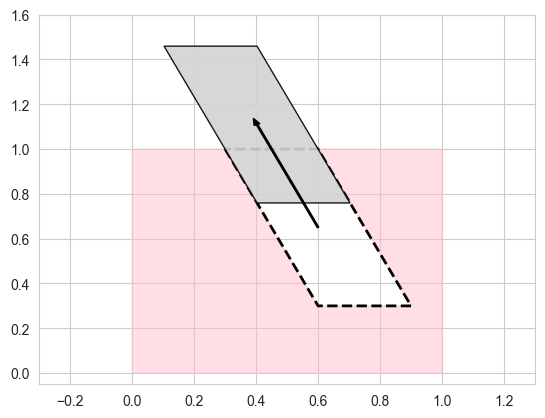

In [185]:
plot_translated(poly4)

# Rotatable Polygon

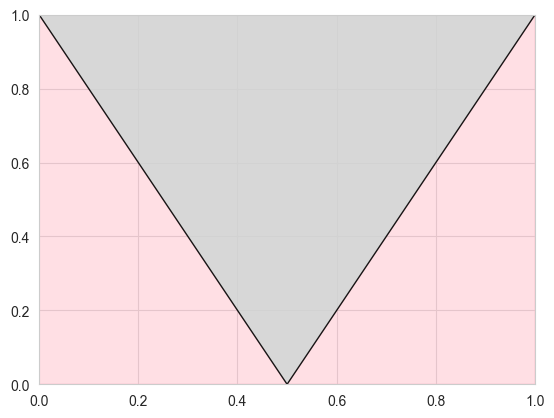

In [186]:
plot_polygon(poly1)

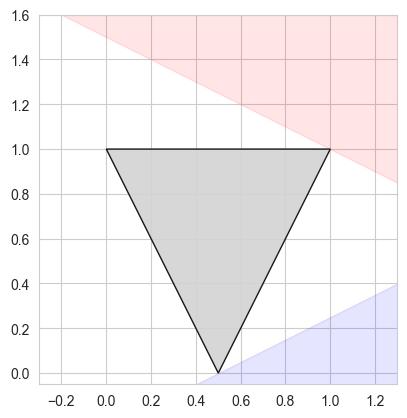

array([[-1.  ,  0.5 , -0.25],
       [ 1.  , -0.5 ,  1.5 ]])

In [192]:
def rotatable_half_planes(polygon, x_lim=(-0.3, 1.3), y_lim=(-0.05, 1.6)):

    edges = get_edges(polygon)

    # y (</>) Mx + B. Store -1/1 to describe y less/more than, M (False if vertical), and B (x-coor if vertical)
    half_planes = np.empty(shape=(len(edges), 3))

    # Setup Plot
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.add_patch(Polygon(polygon, facecolor='lightgray',
                 alpha=0.9, edgecolor='black', lw=1))
    ax.set_xlim(*x_lim)
    ax.set_ylim(*y_lim)

    for i, edge in enumerate(edges):
        p1, p2 = edge[0], edge[1]
        dx, dy = p2 - p1  # Change in x and y
        angle = get_angle(edge)

        # 1. Vertical Constraint Case (dy is 0)
        if np.isclose(dy, 0):
            x_line = p2[0]

            # Shade right if dx > 0, else shade left
            x2_fill = None

            if dx > 0:
                x2_fill = x_lim[1]
                half_planes[i] = 1, np.inf, p2[0]
            else:
                x2_fill = x_lim[0]
                half_planes[i] = -1, np.inf, p2[0]

            plt.fill_betweenx(y=y_lim, x1=x_line, x2=x2_fill,
                              color='red', alpha=0.1)

            continue

        # 2. Sloped Constraint Case
        # Perpendicular slope (m_perp) is -dx / dy
        m_perp = -dx / dy
        x_vals = np.array(x_lim)

        # Point-slope form: y = m(x - x1) + y1
        y_vals = m_perp * (x_vals - p2[0]) + p2[1]

        # y = mx - m*x1 + y1

        if 0 < angle < np.pi:
            # Color Above
            plt.fill_between(
                x_vals, y_vals, y2=y_lim[1], color='red', alpha=0.1)
            half_planes[i] = 1, m_perp, p2[1]-m_perp*p2[0]

        else:
            # Color Below
            plt.fill_between(
                x_vals, y_vals, y2=y_lim[0], color='blue', alpha=0.1)
            half_planes[i] = -1, m_perp, p2[1]-m_perp*p2[0]

    plt.show()
    return half_planes


rotatable_half_planes(poly1)

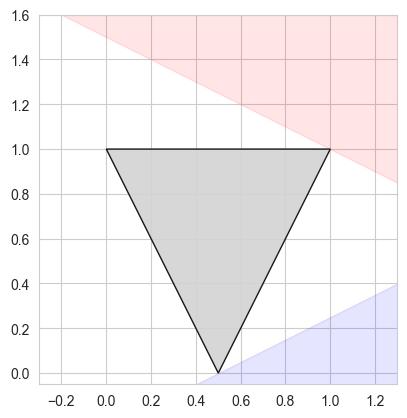

[[-1.    0.5  -0.25]
 [ 1.   -0.5   1.5 ]]


In [ ]:
def rotatable(polygon):
    half_planes = rotatable_half_planes(polygon)
    
    
    
rotatable(poly1)

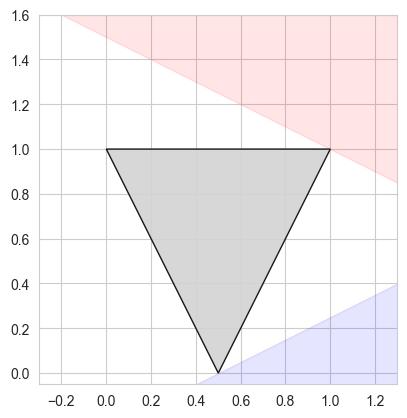

[[-1.    0.5  -0.25]
 [ 1.   -0.5   1.5 ]]


In [188]:
rotatable(poly1)

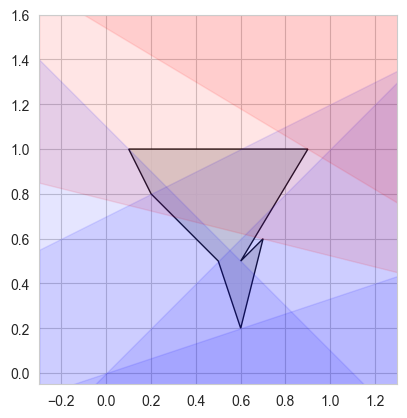

[[-1.00000000e+00  5.00000000e-01  7.00000000e-01]
 [-1.00000000e+00  1.00000000e+00  1.11022302e-16]
 [-1.00000000e+00  3.33333333e-01  5.55111512e-17]
 [ 1.00000000e+00 -2.50000000e-01  7.75000000e-01]
 [-1.00000000e+00 -1.00000000e+00  1.10000000e+00]
 [ 1.00000000e+00 -6.00000000e-01  1.54000000e+00]]


In [189]:
rotatable(poly2)

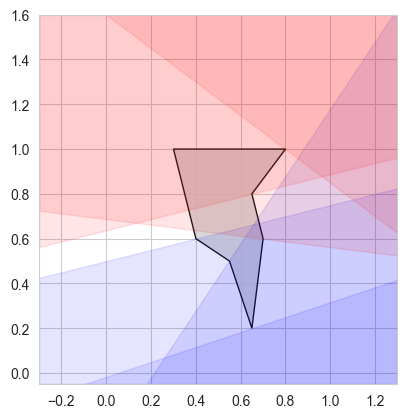

[[-1.          0.25        0.5       ]
 [-1.          1.5        -0.325     ]
 [-1.          0.33333333 -0.01666667]
 [ 1.         -0.125       0.6875    ]
 [ 1.          0.25        0.6375    ]
 [ 1.         -0.75        1.6       ]]


In [190]:
rotatable(poly3)

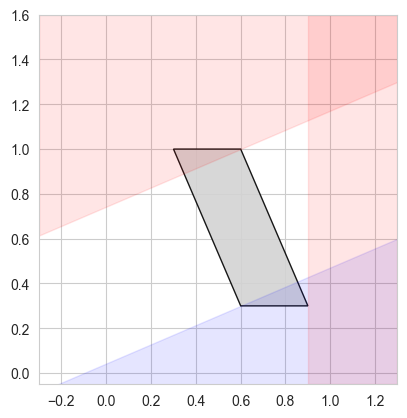

[[-1.          0.42857143  0.04285714]
 [ 1.                 inf  0.9       ]
 [ 1.          0.42857143  0.74285714]]


In [191]:
rotatable(poly4)